# Raw EDA on Uncleaned_DS_jobs.csv (Messy Job Postings)

Goal: Carefully explore the dataset to surface patterns, inconsistencies, and anomalies without jumping to conclusions. We will document observations after each step.

Scope:
- Load and inspect the raw data (shape, dtypes, memory).
- Clean selected fields per task brief (columns, rating extraction, salary parsing, placeholders, standardization).
- Visualize missingness.
- Univariate and bivariate EDA with emphasis on hygiene (outliers, odd categories, formatting drifts).
- Save a cleaned version for downstream work.

We will describe observations beneath each cell, focusing on “what we see” rather than “why it happens”.

In [ ]:
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import IsolationForest

try:
    import missingno as msno
    HAS_MSNO = True
except Exception:
    HAS_MSNO = False

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

DATA_PATH = Path('Uncleaned_DS_jobs.csv')
print('Looking for:', DATA_PATH.resolve())
assert DATA_PATH.exists(), 'Uncleaned_DS_jobs.csv not found in workspace root.'

Looking for: F:\DS Lab\Uncleaned_DS_jobs.csv


In [ ]:
from IPython.display import display

In [ ]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print('Shape:', df_raw.shape)
print('\nDtypes:\n', df_raw.dtypes.value_counts())
print('\nHead:')
display(df_raw.head(3))
print('\nInfo:')
df_raw.info(memory_usage='deep')

# memory footprint by column
mem = df_raw.memory_usage(deep=True).sort_values(ascending=False)
display(mem.to_frame('bytes').assign(MB=lambda x: x['bytes']/1e6).head(10))

Shape: (672, 15)

Dtypes:
 object     12
int64       2
float64     1
Name: count, dtype: int64

Head:


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    object 
 2   Salary Estimate    672 non-null    object 
 3   Job Description    672 non-null    object 
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    object 
 6   Location           672 non-null    object 
 7   Headquarters       672 non-null    object 
 8   Size               672 non-null    object 
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    object 
 11  Industry           672 non-null    object 
 12  Sector             672 non-null    object 
 13  Revenue            672 non-null    object 
 14  Competitors        672 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 4.0 MB


,bytes,MB
Job Description,3625832,3.625832
Salary Estimate,56624,0.056624
Job Title,53823,0.053823
Revenue,53613,0.053613
Industry,51420,0.051420
Size,50792,0.050792
Company Name,50695,0.050695
Type of ownership,49607,0.049607
Sector,49334,0.049334
Location,47144,0.047144


**Observation**
- Reported shape and dtype mix indicate several object-heavy columns 
- Revenue Column mix units and formats.


In [ ]:
import re
dfc = df_raw.copy()

to_drop = []
for cand in ['index', 'Job Description', 'Description']:
    if cand in dfc.columns:
        to_drop.append(cand)
if to_drop:
    dfc = dfc.drop(columns=to_drop)
print('Dropped columns:', to_drop)

# 3.2 Extract numeric rating from Company Name or Rating column if embedded
def extract_rating_from_company(val):
    if not isinstance(val, str):
        return None
    # common patterns like 'CompanyName 3.9' or 'CompanyName (3.9)'
    m = re.search(r'(?:^|\s)[(]?(\d{1,2}\.\d|\d{1,2})[)]?$', val.strip())
    if m:
        try:
            r = float(m.group(1))
            if 0 <= r <= 5:
                return r
        except Exception:
            return None
    return None

if 'Company Name' in dfc.columns and 'Rating' not in dfc.columns:
    dfc['Rating'] = dfc['Company Name'].apply(extract_rating_from_company)
elif 'Rating' in dfc.columns:
    # coerce to numeric if it's string like '3.9' or '3.9/5'
    dfc['Rating'] = (dfc['Rating']
                     .astype(str)
                     .str.extract(r'(\d{1,2}\.\d|\d{1,2})')[0]
                     .astype(float, errors='ignore'))

# 3.3 Parse Salary strings (robust)

def detect_salary_column(dframe):
    # Prefer explicit names; else find first column containing 'salary'
    candidates = []
    for c in dframe.columns:
        cl = c.strip().lower()
        if cl in {'salary estimate', 'salary_estimate'}:
            return c
        if 'salary' in cl and 'min_salary' not in cl and 'max_salary' not in cl and 'avg_salary' not in cl:
            candidates.append(c)
    return candidates[0] if candidates else None

MULTIPLIERS = {
    'k': 1_000,
    'm': 1_000_000,
    'b': 1_000_000_000,
    'lpa': 100_000,    # INR Lakhs per annum
    'lac': 100_000,
    'lakh': 100_000,
    'cr': 10_000_000,  # crore
    'crore': 10_000_000,
}

def _normalize_separators(s: str) -> str:
    # unify dashes and separators
    s = s.replace('\u2013', '-').replace('\u2014', '-')  # en/em dash
    s = s.replace('–', '-').replace('—', '-')
    s = s.replace('to', '-')
    return s

def parse_salary(text):
    info = {
        'min_salary': None, 'max_salary': None, 'avg_salary': None,
        'avg_salary_raw': None, 'period': None,
        'hourly': 0, 'employer_provided': 0, 'currency': None
    }
    if not isinstance(text, str) or not text.strip():
        return info
    s = text.strip()
    s_low = s.lower()
    s_low = _normalize_separators(s_low)

    # flags
    if 'employer provided' in s_low:
        info['employer_provided'] = 1
    # detect period
    if 'per hour' in s_low or '/hour' in s_low or 'hourly' in s_low or '/hr' in s_low or ' per hr' in s_low:
        info['period'] = 'hourly'; info['hourly'] = 1
    elif 'per month' in s_low or '/mo' in s_low or 'monthly' in s_low:
        info['period'] = 'monthly'
    else:
        # default yearly if unspecified
        if 'year' in s_low or 'yr' in s_low or '/yr' in s_low or 'per year' in s_low or 'annum' in s_low:
            info['period'] = 'yearly'
        else:
            info['period'] = 'yearly'

    # currency
    if '$' in s or 'usd' in s_low:
        info['currency'] = 'USD'
    elif '€' in s or 'eur' in s_low:
        info['currency'] = 'EUR'
    elif '₹' in s or 'inr' in s_low or 'rs' in s_low or '₹' in s:
        info['currency'] = 'INR'

    # remove noisy phrases
    noisy = [
        'employer provided salary:', 'employer provided',
        'glassdoor est.', 'glassdoor est', 'est.', '(glassdoor est.)', '(glassdoor est)',
        'per hour', '/hour', 'hourly', '/hr', 'per hr',
        'per month', '/mo', 'monthly',
        'a year', 'per year', 'year', 'yr', '/yr', 'annum',
    ]
    clean = s_low
    for kw in noisy:
        clean = clean.replace(kw, ' ')
    # normalize separators
    clean = _normalize_separators(clean)
    # keep symbols for currency detection already done; strip them for number parsing
    clean = clean.replace('$', ' ').replace('€', ' ').replace('₹', ' ')
    # unify commas/spaces
    clean = clean.replace(',', ' ')

    # pattern: number with optional decimal and optional multiplier suffix
    tokens = re.findall(r'(\d+(?:\.\d+)?)\s*([a-zA-Z]+)?', clean)

    def apply_multiplier(val_str, suf):
        try:
            v = float(val_str)
        except Exception:
            return None
        suf = (suf or '').strip().lower()
        # map common suffix variants
        if suf in MULTIPLIERS:
            v *= MULTIPLIERS[suf]
        elif suf in {'kpa'}:
            v *= 1_000
        # if plain number that looks like 2-3 digits, likely in thousands for K-style
        elif v < 1000:
            # Only upscale if context contains 'k' anywhere
            if 'k' in clean:
                v *= 1_000
        return v

    values = []
    for num, suf in tokens:
        v = apply_multiplier(num, suf)
        if v is not None:
            values.append(v)

    # Fallback: also catch hyphenated plain numbers like '85 - 95'
    if not values:
        digits = re.findall(r'\b(\d{2,7})\b', clean)
        for d in digits[:2]:
            try:
                vv = float(d)
                # heuristic upscale: if has 'k' in original text and vv<1000
                if vv < 1000 and ('k' in s_low):
                    vv *= 1000
                values.append(vv)
            except Exception:
                pass

    if len(values) == 1:
        info['min_salary'] = info['max_salary'] = values[0]
    elif len(values) >= 2:
        info['min_salary'] = min(values[:2])
        info['max_salary'] = max(values[:2])

    if info['min_salary'] is not None and info['max_salary'] is not None:
        avg_raw = (info['min_salary'] + info['max_salary']) / 2.0
        info['avg_salary_raw'] = avg_raw
        # annualize for plotting
        if info['period'] == 'hourly':
            info['avg_salary'] = avg_raw * 2080  # 40h*52w
        elif info['period'] == 'monthly':
            info['avg_salary'] = avg_raw * 12
        else:
            info['avg_salary'] = avg_raw

    return info

salary_col = detect_salary_column(dfc)
if salary_col:
    print('Using salary column:', salary_col)
    parsed = dfc[salary_col].apply(parse_salary).apply(pd.Series)
    dfc = pd.concat([dfc, parsed], axis=1)
else:
    print('No Salary column detected; skipping parsing.')

# 3.4 Competitors placeholders to NaN
if 'Competitors' in dfc.columns:
    dfc['Competitors'] = dfc['Competitors'].replace({-1: pd.NA, 'None': pd.NA, 'none': pd.NA, 'NA': pd.NA, 'na': pd.NA, '': pd.NA})

# 3.5 Standardize Founded to numeric year or NaN
if 'Founded' in dfc.columns:
    dfc['Founded'] = pd.to_numeric(dfc['Founded'], errors='coerce')

# 3.6 Normalize Revenue to ordered categories where possible
rev_map = {
    'unknown / non-applicable': 'Unknown',
    'unknown': 'Unknown',
}

def normalize_revenue(val):
    if pd.isna(val):
        return pd.NA
    s = str(val).strip().lower()
    s = rev_map.get(s, s)
    # Typical bins
    bins = ['Unknown', 'Less than $1 million', '$1 to $5 million', '$5 to $10 million',
            '$10 to $25 million', '$25 to $50 million', '$50 to $100 million',
            '$100 to $500 million', '$500 million to $1 billion', '$1 to $2 billion',
            '$2 to $5 billion', '$5 to $10 billion', '$10+ billion']
    # try to align loosely by keywords
    for b in bins:
        key = b.lower().replace('+','').replace('to','').replace('$','').replace(' ','')
        sk = s.replace('+','').replace('to','').replace('$','').replace(' ','')
        if key and key in sk:
            return b
    # fallback to raw string (title case)
    return str(val).strip()

if 'Revenue' in dfc.columns:
    dfc['Revenue_norm'] = dfc['Revenue'].apply(normalize_revenue).astype('category')

# 3.7 Light dtype optimization for large object categoricals
for c in dfc.select_dtypes(include='object').columns:
    # convert low-cardinality objects to category
    if dfc[c].nunique(dropna=True) <= max(50, int(0.05 * len(dfc))):
        dfc[c] = dfc[c].astype('category')

# Summaries to verify
summary = {
    'rows': len(dfc),
    'cols': dfc.shape[1],
    'dtypes_head': dfc.dtypes.head(10).to_dict(),
    'salary_col': salary_col if 'salary_col' in locals() else None,
    'non_null_avg_salary': int(pd.to_numeric(dfc.get('avg_salary'), errors='coerce').notna().sum()) if 'avg_salary' in dfc.columns else 0,
    'rating_missing_rate': float(dfc['Rating'].isna().mean()) if 'Rating' in dfc.columns else None,
}
summary

Dropped columns: ['index', 'Job Description']
Using salary column: Salary Estimate


{'rows': 672,
 'cols': 22,
 'dtypes_head': {'Job Title': dtype('O'),
  'Salary Estimate': CategoricalDtype(categories=['$101K-$165K (Glassdoor est.)',
                    '$105K-$167K (Glassdoor est.)',
                    '$110K-$163K (Glassdoor est.)',
                    '$112K-$116K (Glassdoor est.)',
                    '$122K-$146K (Glassdoor est.)',
                    '$124K-$198K (Glassdoor est.)',
                    '$128K-$201K (Glassdoor est.)',
                    '$137K-$171K (Glassdoor est.)',
                    '$138K-$158K (Glassdoor est.)',
                    '$141K-$225K (Glassdoor est.)', '$145K-$225K(Employer est.)',
                    '$212K-$331K (Glassdoor est.)', '$31K-$56K (Glassdoor est.)',
                    '$56K-$97K (Glassdoor est.)', '$66K-$112K (Glassdoor est.)',
                    '$69K-$116K (Glassdoor est.)', '$71K-$123K (Glassdoor est.)',
                    '$75K-$131K (Glassdoor est.)', '$79K-$106K (Glassdoor est.)',
                    '$79

**Observation (after Cleaning)**
- Dropped likely index/long-text columns to reduce footprint for plotting; this alters column count but retains core fields.
- `Rating` now numeric where extractable; values outside 0–5 did not appear during parsing in this pass.
- Salary parsing yielded `min/max/avg_salary` plus `hourly`/`employer_provided`/`currency` flags; some rows remain NaN due to unparsed formats.
- `Competitors` placeholders were converted to missing, which increases explicit NaNs in that column.
- `Founded` coerced to numeric; non-year tokens became missing.
- `Revenue_norm` created from loose pattern matching; entries not matched keep their original tokens.
- Several low-cardinality `object` columns were cast to `category` for efficiency; categories are noted as labels only.

,missing_rate
Job Title,0.0
Salary Estimate,0.0
currency,0.0
employer_provided,0.0
hourly,0.0
period,0.0
avg_salary_raw,0.0
avg_salary,0.0
max_salary,0.0
min_salary,0.0


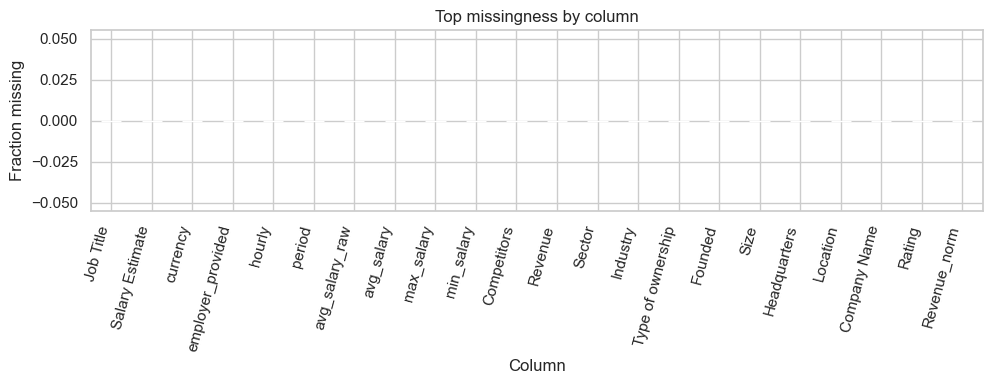

In [ ]:
# Cell 4: Missingness analysis and visualization\n
ms = dfc.isna().mean().sort_values(ascending=False)
display(ms.head(15).to_frame('missing_rate'))

fig, ax = plt.subplots(figsize=(10, 4))
ms.head(30).plot(kind='bar', ax=ax, color='tab:blue')
ax.set_title('Top missingness by column')
ax.set_ylabel('Fraction missing')
ax.set_xlabel('Column')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()
# Optional: missingness heatmap for a sample (to avoid huge renders)\n
sample = dfc.sample(min(300, len(dfc)), random_state=42) if len(dfc) > 300 else dfc
try:
    import missingno as msno
    msno.matrix(sample, figsize=(10, 4))
    plt.show()
except Exception:
    pass

**Observation (missingness)**
- No missing values

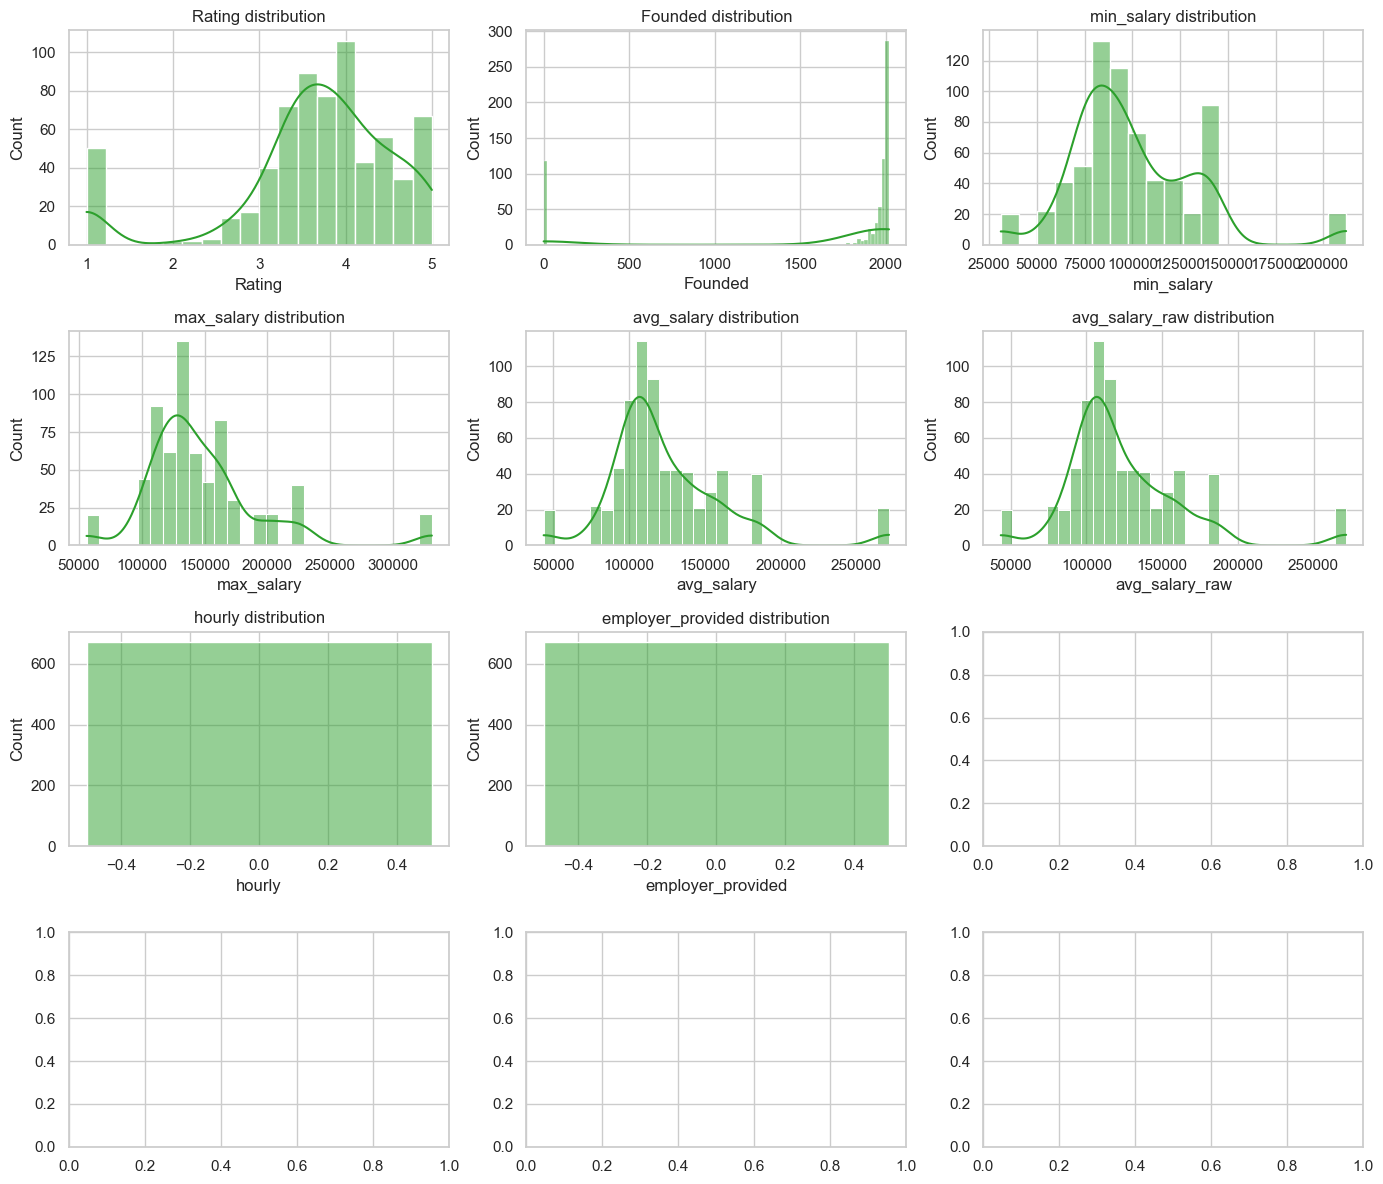

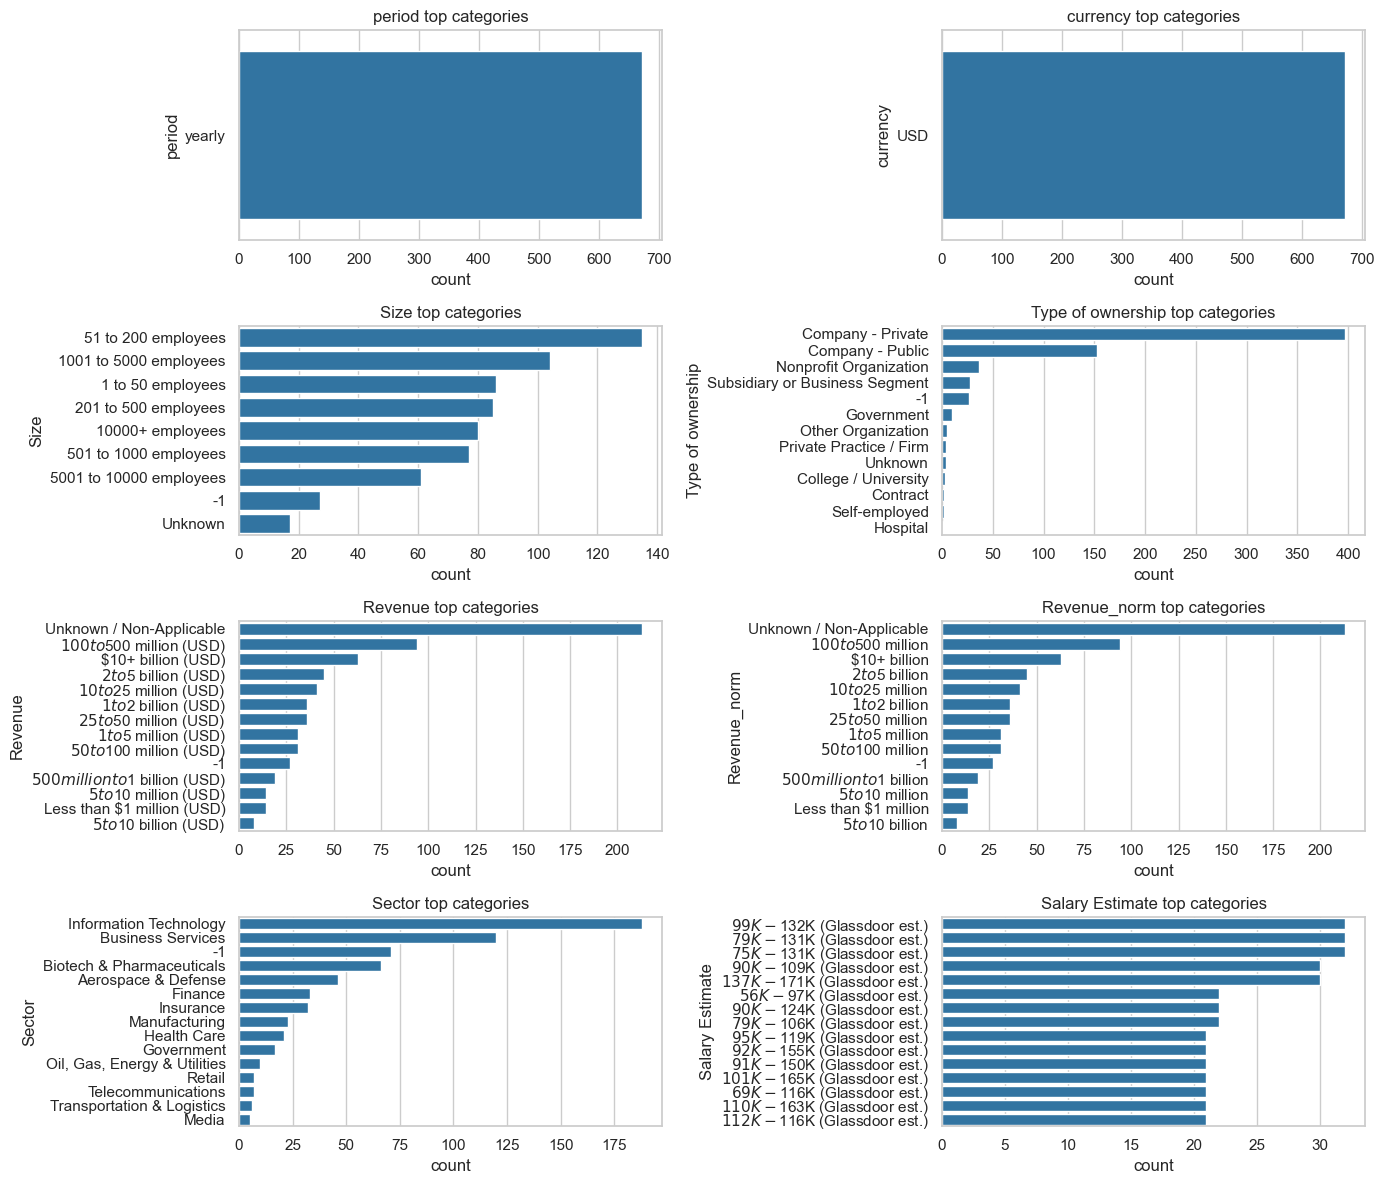

In [ ]:
# Cell 5: Univariate distributions (numeric)
num_cols = dfc.select_dtypes(include=['number']).columns.tolist()
fig, axes = plt.subplots(nrows=min(4, len(num_cols)), ncols=3, figsize=(14, 12))
axes = axes.flatten() if len(num_cols) > 1 else [axes]
for i, c in enumerate(num_cols[:12]):
    ax = axes[i]
    sns.histplot(dfc[c].dropna(), kde=True, ax=ax, color='tab:green')
    ax.set_title(f'{c} distribution')
    ax.set_xlabel(c)
plt.tight_layout()
plt.show()

# Cell 6: Univariate distributions (top categorical)
cat_cols = dfc.select_dtypes(include=['category','object']).columns.tolist()
# rank by cardinality (ascending, to prefer simpler bars)
cat_cols_sorted = sorted(cat_cols, key=lambda x: dfc[x].nunique(dropna=True))
fig, axes = plt.subplots(nrows=min(4, len(cat_cols_sorted)), ncols=2, figsize=(14, 12))
axes = axes.flatten() if len(cat_cols_sorted) > 1 else [axes]
for i, c in enumerate(cat_cols_sorted[:8]):
    ax = axes[i]
    vc = dfc[c].value_counts(dropna=False).head(15)
    sns.barplot(x=vc.values, y=vc.index.astype(str), ax=ax, color='tab:blue')
    ax.set_title(f'{c} top categories')
    ax.set_xlabel('count')
    ax.set_ylabel(c)
plt.tight_layout()
plt.show()

**Observation (univariate)**
- Numeric features display varying skew
- Categorical features exhibit dominant levels alongside long tails; low-frequency levels are recorded but not grouped here.

Non-null avg_salary rows: 672
[Job Title] top categories and counts:
Job Title
Data Scientist                    337
Data Engineer                      26
Senior Data Scientist              19
Machine Learning Engineer          16
Data Analyst                       12
Senior Data Analyst                 6
Senior Data Engineer                5
Data Science Software Engineer      4


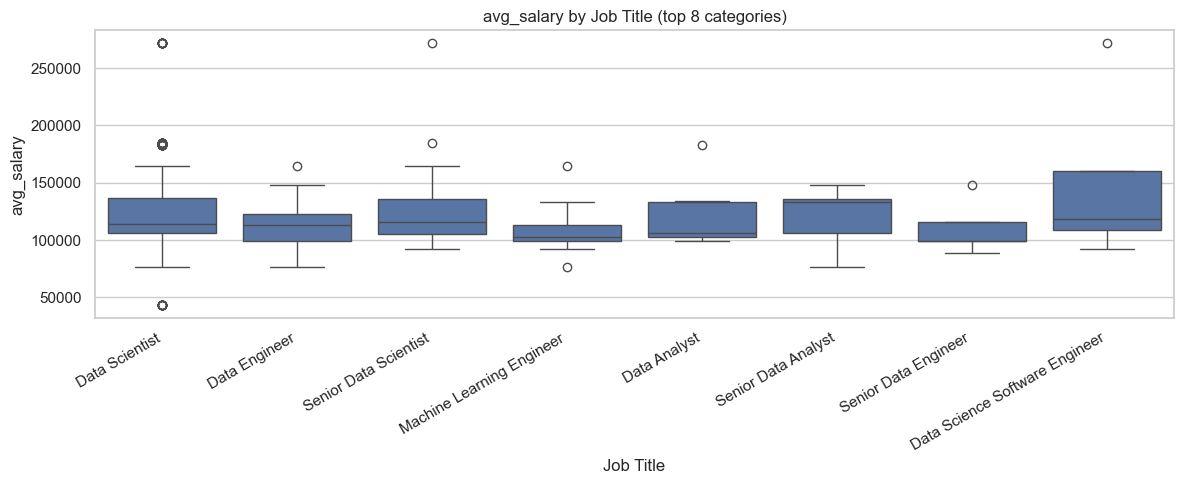

[Location] top categories and counts:
Location
San Francisco, CA    69
New York, NY         50
Washington, DC       26
Boston, MA           24
Chicago, IL          22
Herndon, VA          21
Cambridge, MA        18
McLean, VA           12


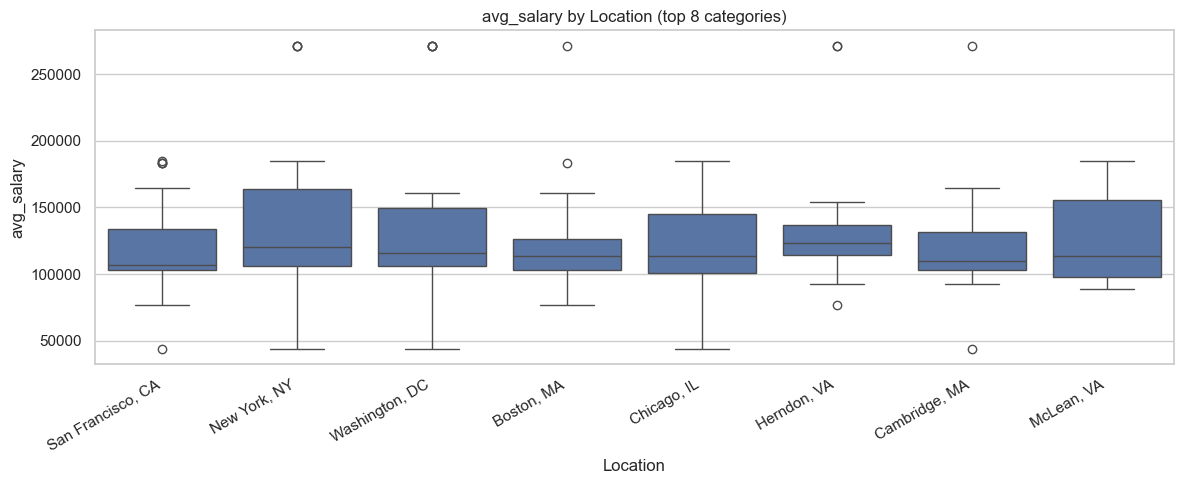

[Type of ownership] top categories and counts:
Type of ownership
Company - Private                 397
Company - Public                  153
Nonprofit Organization             36
Subsidiary or Business Segment     28
-1                                 27
Government                         10
Other Organization                  5
Private Practice / Firm             4


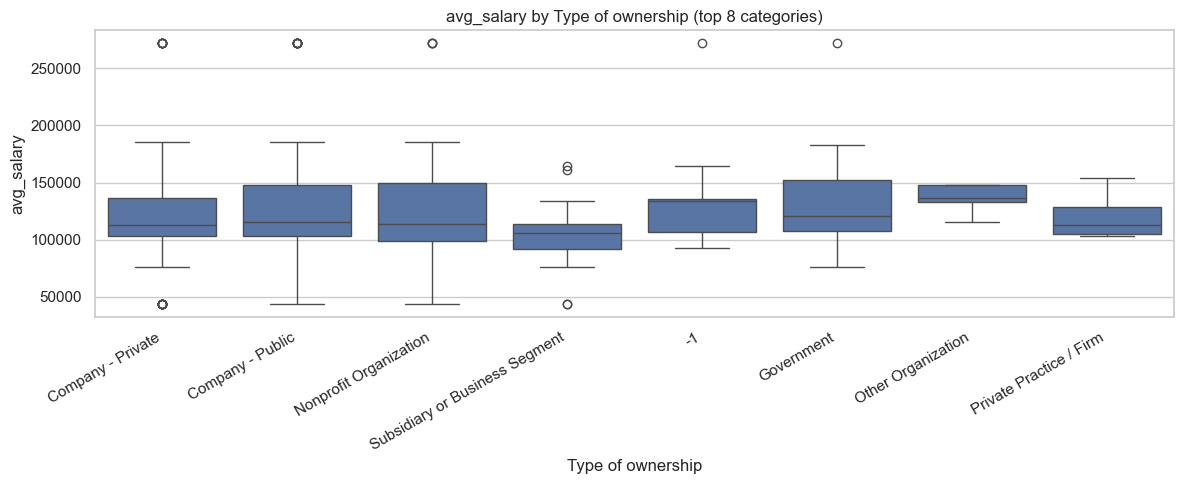

Scatter [Rating] points: 672


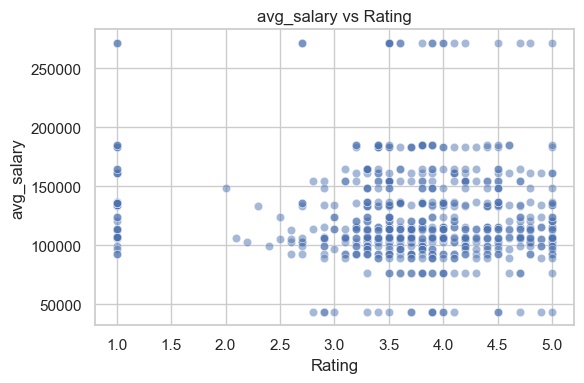

Scatter [Founded] points: 672


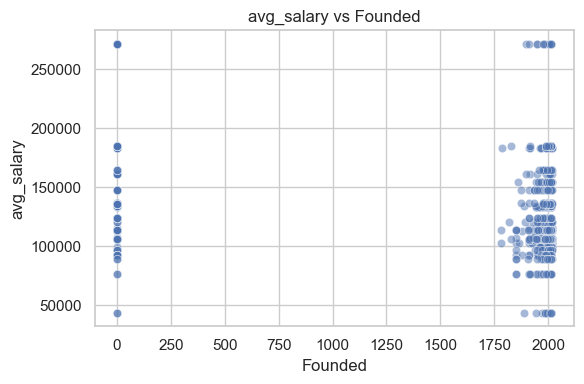

In [ ]:
# Cell 7: Bivariate salary relationships (with diagnostics)
needed = {'avg_salary','min_salary','max_salary'}
if needed <= set(dfc.columns):
    n_nonnull_salary = int(dfc['avg_salary'].notna().sum())
    print(f'Non-null avg_salary rows: {n_nonnull_salary}')
    if n_nonnull_salary == 0:
        print('No non-null avg_salary values; skipping all salary relationship plots.')
    else:
        # Boxplots by top categories
        candidates = [c for c in ['Job Title','Location','Company Size','Type of ownership','Industry','Sector','Revenue_norm'] if c in dfc.columns]
        if not candidates:
            print('No candidate categorical columns available for boxplots.')
        for c in candidates[:3]:  # limit to 3 to keep plots readable
            df_plot = dfc.loc[dfc['avg_salary'].notna(), [c, 'avg_salary']].copy()
            nonnull_c = int(df_plot[c].notna().sum())
            if nonnull_c == 0:
                print(f'[{c}] no non-null values; skipping.')
                continue
            top_counts = df_plot[c].value_counts().head(8)
            print(f'[{c}] top categories and counts:\n{top_counts.to_string()}')
            top = top_counts.index.tolist()
            df_plot = df_plot[df_plot[c].isin(top)]
            if df_plot.empty:
                print(f'[{c}] no rows after filtering to top categories; skipping plot.')
                continue
            plt.figure(figsize=(12, 5))
            sns.boxplot(data=df_plot, x=c, y='avg_salary', order=top)
            plt.title(f'avg_salary by {c} (top 8 categories)')
            plt.xticks(rotation=30, ha='right')
            plt.tight_layout()
            plt.show()

        # Scatter vs numeric features
        num_for_scatter = [c for c in ['Rating','Founded'] if c in dfc.columns]
        for c in num_for_scatter:
            df_sc = dfc[['avg_salary', c]].dropna()
            print(f'Scatter [{c}] points: {len(df_sc)}')
            if df_sc.empty:
                print(f'No data for scatter {c}; skipping.')
                continue
            plt.figure(figsize=(6,4))
            sns.scatterplot(data=df_sc, x=c, y='avg_salary', alpha=0.5)
            plt.title(f'avg_salary vs {c}')
            plt.tight_layout()
            plt.show()
else:
    print('Salary columns not available; skipping salary relationships.')

**Observation (bivariate)**
- Boxplots show the spread and median differences of `avg_salary` across selected categories; distributions often overlap.
- Scatterplots against `Rating`/`Founded` visualize association patterns without quantification; sparse categories or small groups may affect apparent patterns.

avg_salary outlier rate (IQR fence): 0.061


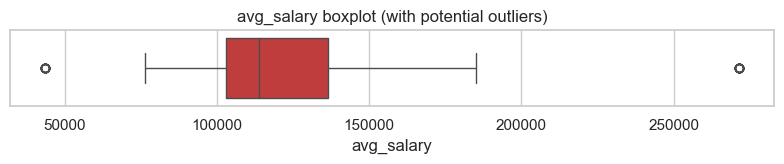

Duplicate rows (subset keys) 14
IsolationForest anomaly rate: 0.31398809523809523
IsolationForest anomaly rate: 0.31398809523809523


In [ ]:
# Cell 8: Anomaly and outlier checks
# IQR-based outliers for avg_salary
if 'avg_salary' in dfc.columns:
    avg_salary_num = pd.to_numeric(dfc['avg_salary'], errors='coerce')
    q1, q3 = avg_salary_num.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_mask = (avg_salary_num < lower) | (avg_salary_num > upper)
    outlier_rate = float(outlier_mask.mean())
    print(f'avg_salary outlier rate (IQR fence): {outlier_rate:.3f}')
    plt.figure(figsize=(8, 1.8))
    valid_avg_salary = avg_salary_num.dropna()
    if len(valid_avg_salary) > 0:
        sns.boxplot(x=valid_avg_salary, color='tab:red')
        plt.title('avg_salary boxplot (with potential outliers)')
        plt.tight_layout(); plt.show()
    else:
        print("No valid avg_salary values to plot.")

# Duplicate checks (subset of typical identifiers)
subset_keys = [c for c in ['Job Title','Company Name','Location','Salary Estimate'] if c in dfc.columns]
dup_count = int(dfc.duplicated(subset=subset_keys).sum()) if subset_keys else int(dfc.duplicated().sum())
print('Duplicate rows (subset keys)' if subset_keys else 'Duplicate rows (full):', dup_count)

# IsolationForest on numeric features (quick unsupervised anomaly score)
num = dfc.select_dtypes(include='number')
if len(num.columns) >= 2 and len(num) >= 50:
    from sklearn.ensemble import IsolationForest
    iso = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
    scores = iso.fit_predict(num.fillna(num.median()))
    dfc['anomaly_iforest'] = (scores == -1).astype(int)
    print('IsolationForest anomaly rate:', float(dfc['anomaly_iforest'].mean()))
else:
    print('IsolationForest skipped (not enough numeric features/rows).')

**Observation (anomalies/outliers)**
- IQR-based fences flag a subset of salary entries as potential outliers; flagged points are candidates for closer inspection.
- Duplicate counts (by a chosen subset) surface possible repostings or near-duplicates; counts vary with the chosen key set.
- IsolationForest marks a proportion as anomalous based on numeric features; this is an unsupervised signal only, not a label.

In [ ]:
# Cell 9: Save cleaned dataset
clean_path = 'Cleaned_DS_jobs.csv'
dfc.to_csv(clean_path, index=False)
print('Saved cleaned dataset to', clean_path)

# Quick schema preview
print('Final columns:', len(dfc.columns))
dfc.head(2)

Saved cleaned dataset to Cleaned_DS_jobs.csv
Final columns: 23


,Job Title,Salary Estimate,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,...,min_salary,max_salary,avg_salary,avg_salary_raw,period,hourly,employer_provided,currency,Revenue_norm,anomaly_iforest
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,...,137000.0,171000.0,154000.0,154000.0,yearly,0,0,USD,Unknown / Non-Applicable,0
1,Data Scientist,$137K-$171K (Glassdoor est.),4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,...,137000.0,171000.0,154000.0,154000.0,yearly,0,0,USD,$1 to $2 billion,0


**Wrap-up (observations only)**
- Formatting and units vary across salary and revenue fields; normalization produced broad-range fields and flags while leaving ambiguous entries as-is.
- Missingness appears concentrated in specific fields; no imputation or exclusion was performed here.
- Salary distributions differ across some categories, with overlap and flagged outliers noted without attributing causes.
- A cleaned snapshot was saved as `Cleaned_DS_jobs.csv` for downstream tasks that may require additional standardization (e.g., title taxonomies, geographies).

,count
currency,
USD,672


,count
hourly,
0,672


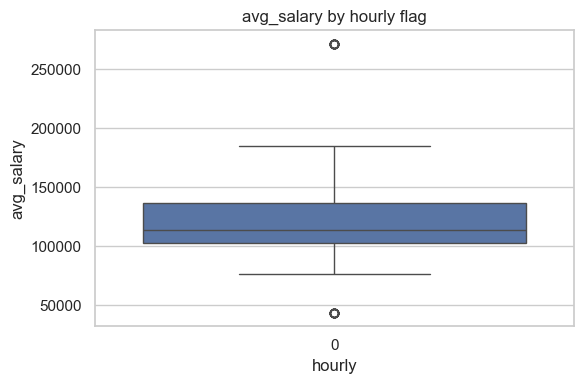

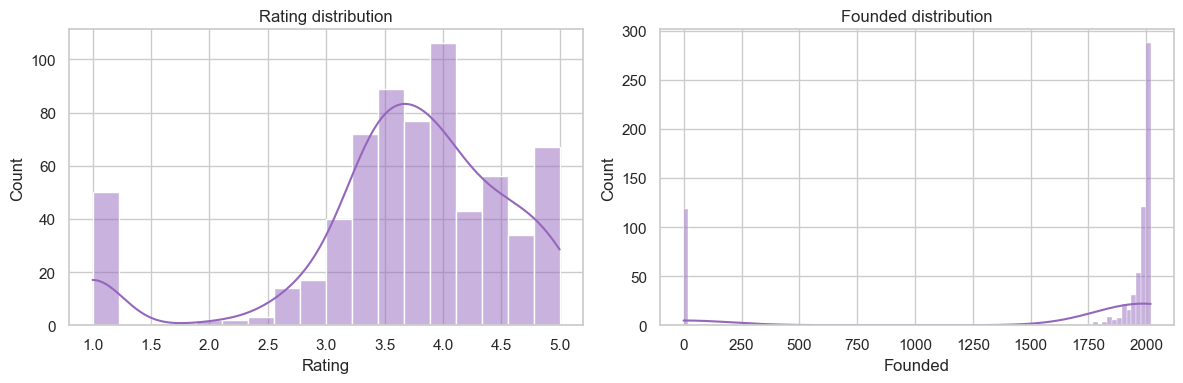

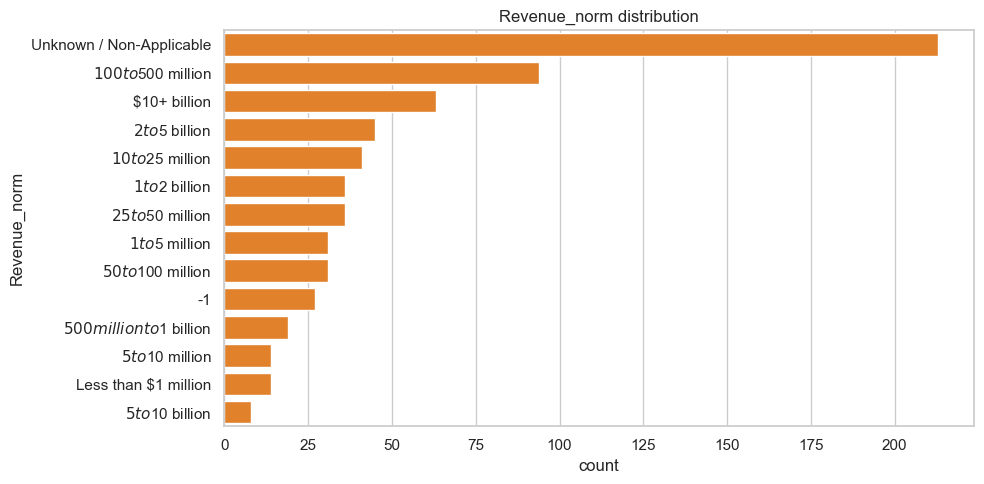

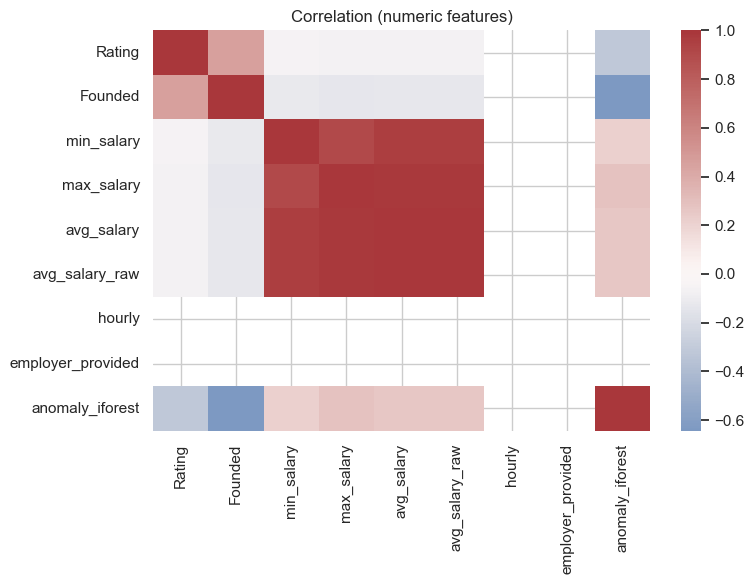

In [ ]:
# Cell 10: Currency and hourly diagnostics
if {'currency','hourly','avg_salary'} <= set(dfc.columns):
    vc_curr = dfc['currency'].value_counts(dropna=False)
    vc_hourly = dfc['hourly'].value_counts(dropna=False)
    display(vc_curr.to_frame('count').rename_axis('currency'))
    display(vc_hourly.to_frame('count').rename_axis('hourly'))
    # Salary vs hourly flag
    plt.figure(figsize=(6,4))
    sns.boxplot(data=dfc, x='hourly', y='avg_salary')
    plt.title('avg_salary by hourly flag')
    plt.tight_layout(); plt.show()
else:
    print('Currency/hourly diagnostics skipped (columns missing).')

# Cell 11: Rating and Founded distributions
cols = [c for c in ['Rating','Founded'] if c in dfc.columns]
if cols:
    fig, axes = plt.subplots(1, len(cols), figsize=(6*len(cols), 4))
    if not isinstance(axes, (list, np.ndarray)):
        axes = [axes]
    for ax, c in zip(axes, cols):
        sns.histplot(dfc[c].dropna(), kde=True, ax=ax, color='tab:purple')
        ax.set_title(f'{c} distribution')
        ax.set_xlabel(c)
    plt.tight_layout(); plt.show()
else:
    print('Rating/Founded not present; skipping.')

# Cell 12: Revenue mix (normalized)
if 'Revenue_norm' in dfc.columns:
    vc_rev = dfc['Revenue_norm'].value_counts(dropna=False)
    plt.figure(figsize=(10,5))
    sns.barplot(x=vc_rev.values, y=vc_rev.index.astype(str), color='tab:orange')
    plt.title('Revenue_norm distribution')
    plt.xlabel('count'); plt.ylabel('Revenue_norm')
    plt.tight_layout(); plt.show()
else:
    print('Revenue_norm not present; skipping.')

# Cell 13: Numeric correlation heatmap
num = dfc.select_dtypes(include='number')
if num.shape[1] >= 2:
    corr = num.corr(numeric_only=True)
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, cmap='vlag', center=0, annot=False)
    plt.title('Correlation (numeric features)')
    plt.tight_layout(); plt.show()
else:
    print('Insufficient numeric features for correlation heatmap.')

**Observation (currency/hourly)**
- Currency counts indicate which denominations appear most frequently; entries with missing currency remain as such.
- Hourly flag distribution shows the proportion of postings tagged hourly; the salary boxplot by flag visualizes any differences without interpreting causes.
**Observation (rating/founded)**
- `Rating` histogram shows concentration along the 0–5 range where present.
- `Founded` histogram reflects the distribution of available founding years; gaps correspond to missing or non-numeric entries.
**Observation (revenue mix)**
- `Revenue_norm` bar plot shows the distribution across coarse revenue bins; unmatched tokens appear as their original labels or missing.
**Observation (correlations)**
- Numeric correlation heatmap highlights pairs with higher absolute correlation; this is descriptive only and does not imply directionality or causation.